In [1]:
import get_ps_21cmEMU
import numpy as np
from getdist import MCSamples, plots
import torch
_ = torch.manual_seed(0)
import matplotlib.pyplot as plt
# plt.style.use('sty.mplstyle')

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [2]:
# calling the emulator and getting the 1D power spectrum training data set

redshift_value = 8.01
# fiducial parameters for the emulator
log_f_star10 = -1.2
alpha_star = 0.5
t_star = 0.55
log_f_esc10 = -1.3
alpha_esc = 0
log_f_star7_mini = -2.5
log_f_esc7_mini = -1.5
log_l_x = 40.0
log_l_x_mini = 41.5
nu_x_thresh = 500
sigma_8 = 0.8118


astro_params = {"F_STAR10": log_f_star10, 
          'ALPHA_STAR': alpha_star,
          't_STAR': t_star,
          'F_ESC10': log_f_esc10,
          'ALPHA_ESC': alpha_esc,
          'F_STAR7_MINI': log_f_star7_mini,
          'F_ESC7_MINI': log_f_esc7_mini,
          'L_X': log_l_x,
          'L_X_MINI': log_l_x_mini,
          'NU_X_THRESH': nu_x_thresh,
          'SIGMA_8': sigma_8
         }

ps_1_d = get_ps_21cmEMU.simu_1d_ps(astro_params, redshift_value = redshift_value)
# noise_sigma = np.load("data/sigma_pk_z8.01_108_hours.npy")
noise_sigma = np.load("data/sigma_pk_z8.01.npy")



def get_traning_data(theta, num_simulations):
    "first varying only three parameters: F_STAR10, F_ESC10, ALPHA_STAR"
    # theta may live on GPU (e.g. sampled from a CUDA prior/posterior); the
    # emulator itself is CPU/numpy-based, so bring the parameters back first.
    if torch.is_tensor(theta):
        theta = theta.detach().cpu().numpy()
    f_star_10 = theta[:, 0]
    f_esc_10 = theta[:, 1]
    alpha_star = theta[:, 2]
    # print(f_star_10, f_esc_10, alpha_star)

    ps_data = np.zeros((num_simulations, 32))

    for i in range(num_simulations):
        astro_params = {"F_STAR10": f_star_10[i], 
          'ALPHA_STAR': alpha_star[i],
          't_STAR': t_star,
          'F_ESC10': f_esc_10[i],
          'ALPHA_ESC': alpha_esc,
          'F_STAR7_MINI': log_f_star7_mini,
          'F_ESC7_MINI': log_f_esc7_mini,
          'L_X': log_l_x,
          'L_X_MINI': log_l_x_mini,
          'NU_X_THRESH': nu_x_thresh,
          'SIGMA_8': sigma_8
         }
        ps = get_ps_21cmEMU.simu_1d_ps(astro_params, redshift_value = redshift_value)
        # noise_sigma = 0.05 * ps # 5% noise level
        # noise_sigma = 0.2 * ps # 5% noise level

        np.random.seed(i)  # for reproducibility
        ps_noisy = ps + np.random.normal(0, noise_sigma, size=ps.shape) # add noise to the power spectrum
        ps_data[i, :] = ps_noisy
        
    return ps_data

In [3]:
# defining the parameter space for training data generation
from sbi.utils import BoxUniform
lower_bounds = np.array([-2.0, -3.0, 0.0])  # lower bounds for F_STAR10, F_ESC10, ALPHA_STAR
upper_bounds = np.array([-0.5, 0.0, 1.0])  # upper bounds for F_STAR10, F_ESC10, ALPHA_STAR
prior = BoxUniform(low=torch.tensor(lower_bounds), high=torch.tensor(upper_bounds), device=device)


In [57]:
# choosing the sbi method for inference: NPE
from sbi.inference import NPE
# inference = NPE(prior=prior, device=device)
#  
# from sbi.neural_nets import posterior_nn
# from sbi.inference import NPE
# density_estimator_build_fun = posterior_nn(
#     model="maf", hidden_features=50, num_transforms=12
# )
# inference = NPE(prior=prior, density_estimator=density_estimator_build_fun, device=device)

from sbi.neural_nets import posterior_nn
from sbi.inference import NPE
density_estimator_build_fun = posterior_nn(
    model="nsf", hidden_features=50, num_transforms=12
)

inference = NPE(prior=prior, density_estimator=density_estimator_build_fun, device=device)

In [58]:
# creating the training data set
num_simulations = 10000
theta = prior.sample((num_simulations,))
# x = get_traning_data(theta, num_simulations)
# x_torch = torch.tensor(x, dtype=torch.float32)
theta = np.load('data/theta_training_data_f_star10_f_esc10_alpha_star_ska_1080_num_simulations_30000.npy')
x = np.load('data/ps_training_data_f_star10_f_esc10_alpha_star_ska_1080_num_simulations_30000.npy')
x_torch = torch.tensor(x, dtype=torch.float32, device=device)
theta_torch = torch.tensor(theta, dtype=torch.float32, device=device)

In [29]:
# np.save('/home/leon/Documents/codes/sbi_21cm_ps/data/ps_training_data_f_star10_f_esc10_alpha_star.npy', x)
# np.save('/home/leon/Documents/codes/sbi_21cm_ps/data/theta_training_data_f_star10_f_esc10_alpha_star.npy', theta)

# np.save('/home/leon/Documents/codes/sbi_21cm_ps/data/ps_training_data_f_star10_f_esc10_alpha_star_10_per_error.npy', x)
# np.save('/home/leon/Documents/codes/sbi_21cm_ps/data/theta_training_data_f_star10_f_esc10_alpha_star_10_per_error.npy', theta)

In [30]:
# np.save('data/ps_training_data_f_star10_f_esc10_alpha_star_ska_108_num_simulations_10000.npy', x)
# np.save('data/theta_training_data_f_star10_f_esc10_alpha_star_ska_108_num_simulations_10000.npy', theta)
# np.save('data/ps_training_data_f_star10_f_esc10_alpha_star_ska_1080_num_simulations_10000.npy', x)
# np.save('data/theta_training_data_f_star10_f_esc10_alpha_star_ska_1080_num_simulations_10000.npy', theta.cpu().numpy())

In [59]:
# training the density estimator with the training data set
inference = inference.append_simulations(theta_torch, x_torch)
density_estimator = inference.train()

/home/leon/anaconda3/lib/python3.13/site-packages/sbi/inference/trainers/npe/npe_base.py:184: UserWarning: Data x has device 'cuda:0'. Moving x to the data_device 'cuda'. Training will proceed on device 'cuda'.
  theta, x = validate_theta_and_x(
/home/leon/anaconda3/lib/python3.13/site-packages/sbi/inference/trainers/npe/npe_base.py:184: UserWarning: Parameters theta has device 'cuda:0'. Moving theta to the data_device 'cuda'. Training will proceed on device 'cuda'.
  theta, x = validate_theta_and_x(


 Neural network successfully converged after 72 epochs.

In [60]:
posterior = inference.build_posterior()
print(posterior)


Posterior p(θ|x) of type DirectPosterior. It samples the posterior network and rejects samples that
            lie outside of the prior bounds.


In [ ]:
# import pickle
# with open("trained_models/npe_nsf_hidden_features_50_num_transforms_12.pkl", "wb") as handle:
#     pickle.dump(posterior, handle)

In [61]:
ps_obs = get_ps_21cmEMU.simu_1d_ps(astro_params, redshift_value = redshift_value) # test data for inference
ps_obs_torch = torch.tensor(ps_obs, dtype=torch.float32, device=device)

In [62]:
posterior_samples = posterior.sample((1000,), x=ps_obs_torch) # draw 1000 posterior samples

  0%|          | 0/1000 [00:00<?, ?it/s]

/home/leon/anaconda3/lib/python3.13/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2273.)
  outputs, _ = torch.triangular_solve(


Removed no burn in


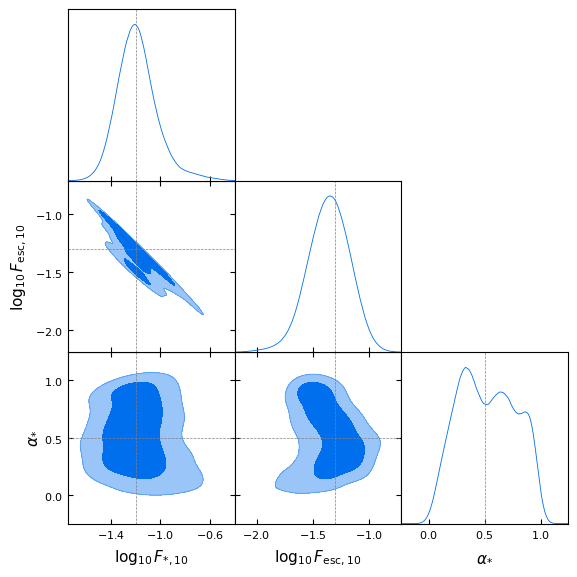

In [63]:
labels = [r'\log_{10} F_{*,10}', r'\log_{10} F_{\rm esc,10}', r'\alpha_{*}']
names = ['F_STAR10', 'F_ESC10', 'ALPHA_STAR']
true_params = [log_f_star10, log_f_esc10, alpha_star]

samples = MCSamples(
    samples=posterior_samples.cpu().numpy(), 
    names=names,
    labels=labels
)

# dictionary mapping the parameter names to their true values
markers_dict = {name: val for name, val in zip(names, true_params)}

g = plots.get_subplot_plotter()
g.triangle_plot(samples, filled=True, markers=markers_dict)

In [64]:
f_star_100_samples = theta_torch[:100, 0].cpu().numpy() 
f_esc_100_samples = theta_torch[:100, 1].cpu().numpy()  
alpha_star_samples = theta_torch[:100, 2].cpu().numpy() 

### Posterior Predictive Checks

In [65]:
theta_posterior_ppc = posterior.sample((200,), x=ps_obs_torch) # draw 1000 posterior samples for posterior predictive check
x_predictive = get_traning_data(theta_posterior_ppc, 200) # generate predictive data from the posterior samples

  0%|          | 0/200 [00:00<?, ?it/s]

In [66]:
x_predictive = torch.tensor(x_predictive, dtype=torch.float32)

In [67]:
x_predictive_mean = torch.mean(x_predictive, axis=0)
print("Posterior predictives: ", x_predictive_mean)

Posterior predictives:  tensor([ 0.7991,  0.9775,  1.1131,  1.3226,  1.8894,  2.2823,  2.6657,  3.2569,
         3.9529,  5.1637,  6.3760,  7.1488,  8.3344,  9.7657, 10.4999, 11.6377,
        12.3287, 13.0351, 13.3804, 13.6291, 13.6016, 13.7645, 13.8957, 13.9778,
        13.7842, 13.9746, 14.3881, 14.7834, 15.5441, 16.2441, 17.2105, 20.5491])


In [68]:
print("Posterior predictives: ", torch.mean(x_predictive, axis=0))
print("Observation: ", ps_obs_torch)

Posterior predictives:  tensor([ 0.7991,  0.9775,  1.1131,  1.3226,  1.8894,  2.2823,  2.6657,  3.2569,
         3.9529,  5.1637,  6.3760,  7.1488,  8.3344,  9.7657, 10.4999, 11.6377,
        12.3287, 13.0351, 13.3804, 13.6291, 13.6016, 13.7645, 13.8957, 13.9778,
        13.7842, 13.9746, 14.3881, 14.7834, 15.5441, 16.2441, 17.2105, 20.5491])
Observation:  tensor([ 0.7266,  0.8724,  1.0713,  1.3827,  1.7752,  2.2211,  2.6790,  3.1785,
         3.9449,  5.0535,  6.2074,  7.0579,  8.2391,  9.6622, 10.3917, 11.6461,
        12.2549, 12.8786, 13.3773, 13.5068, 13.7835, 13.7762, 13.7684, 13.8232,
        13.7977, 13.9439, 14.1603, 14.5238, 15.1517, 16.0082, 17.6302, 20.4022],
       device='cuda:0')


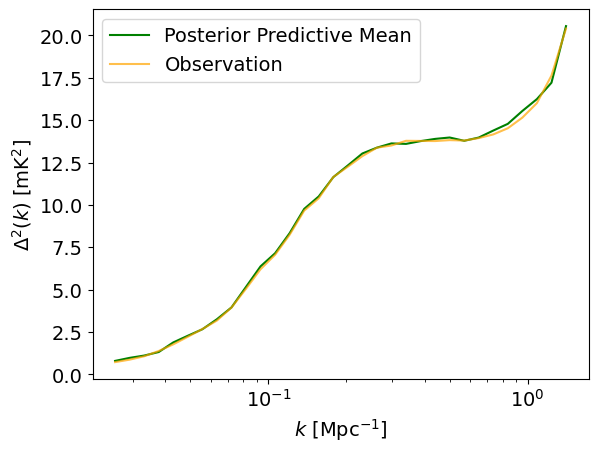

In [69]:
k_values = np.load('data/k_values.npy')
plt.plot(k_values, torch.mean(x_predictive, axis=0), label='Posterior Predictive Mean', color='green')
# plt.errorbar(k_values, torch.mean(x_predictive, axis=0), yerr=torch.std(x_predictive, axis=0), color='green', alpha=0.5, label='Posterior Predictive Std Dev')
plt.plot(k_values, ps_obs_torch.cpu(), label='Observation', color='orange', alpha=0.7)
plt.xscale('log')
plt.xlabel(r'$k$ [Mpc$^{-1}$]')
plt.ylabel(r'$\Delta^2(k)$ [mK$^2$]')
plt.legend()
plt.show()

### Simulation-Based Calibration (SBC)

In [70]:
from sbi.diagnostics import run_sbc
from sbi.analysis.plot import sbc_rank_plot

# Obtain your `posterior_estimator` with NPE, NLE, NRE.
posterior = inference.build_posterior()

num_sbc_samples = 200  # choose a number of sbc runs, should be ~100s
prior_samples = prior.sample((num_sbc_samples,))
prior_predictives = get_traning_data(prior_samples, num_sbc_samples)  # generate predictive data from the prior samples


Sampling 200 times (1000,) posterior samples.: 100%|██████████| 200/200 [00:22<00:00,  8.81it/s]


Calculating ranks for 200 SBC samples:   0%|          | 0/200 [00:00<?, ?it/s]

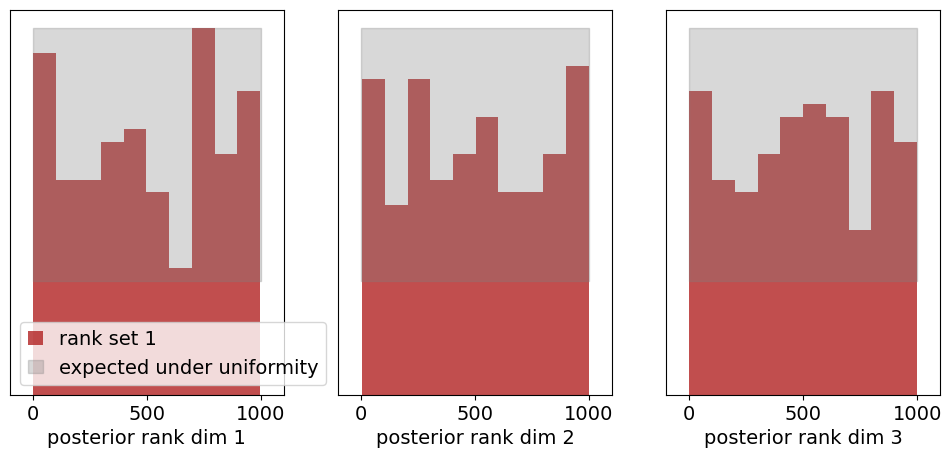

In [71]:

# run SBC: for each inference we draw 1000 posterior samples.
num_posterior_samples = 1_000
ranks, dap_samples = run_sbc(
    prior_samples,
    torch.tensor(prior_predictives, dtype=torch.float32, device=device),
    posterior,
    num_posterior_samples=num_posterior_samples,
    use_batched_sampling=False,  # `True` can give speed-ups, but can cause memory issues.
)
# fig, ax = sbc_rank_plot(
#     ranks,
#     num_posterior_samples,
#     num_bins=20,
#     figsize=(5, 3),
# )
fig, ax = sbc_rank_plot(
    ranks=ranks.cpu(),
    num_posterior_samples=num_posterior_samples,
    plot_type="hist",
    num_bins=None,  
)

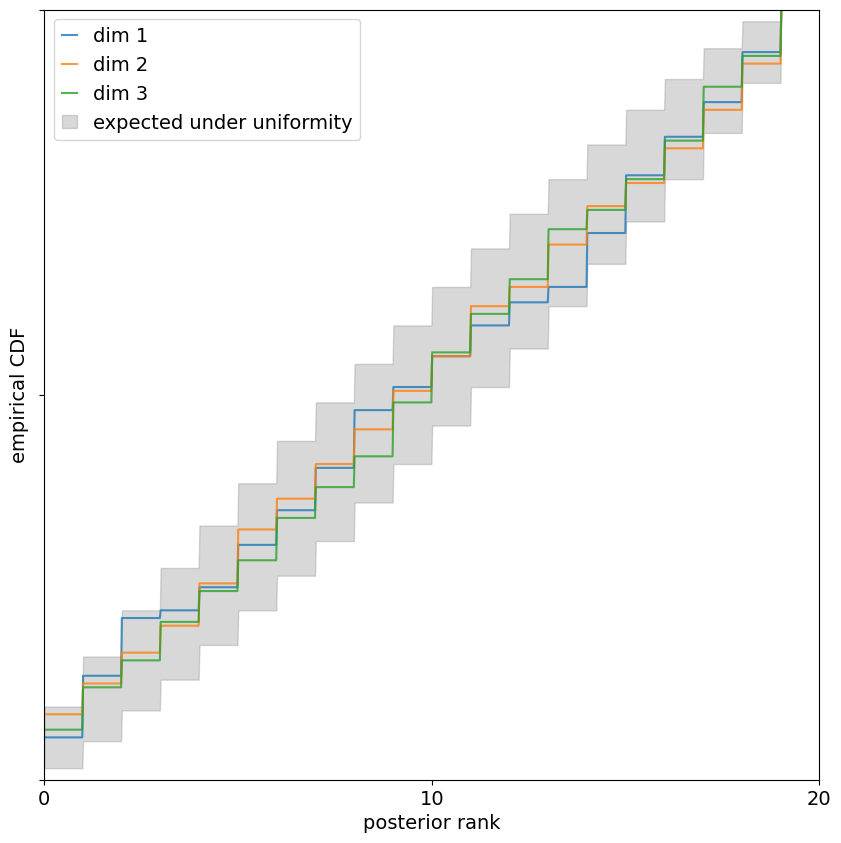

In [72]:
fig, ax = sbc_rank_plot(
    ranks,
    num_posterior_samples,
    num_bins=20,
    figsize=(10, 10),
)

### Posterior calibration with TARP

In [73]:
num_tarp_samples = 200  
thetas = prior.sample((num_tarp_samples,))
xs = get_traning_data(thetas, num_tarp_samples)

In [74]:
from sbi.diagnostics import run_tarp
ecp, alpha = run_tarp(
    thetas,
    torch.tensor(xs, dtype=torch.float32, device=device),
    posterior,
    references=None,  # will be calculated automatically.
    num_posterior_samples=1000,
)

/home/leon/anaconda3/lib/python3.13/site-packages/sbi/utils/diagnostics_utils.py:45: UserWarning: Capping max_sampling_batch_size from 10000 to 500 to avoid excessive memory usage.
  posterior_samples = posterior.sample_batched(


Drawing 1000 samples for 200 observations:   0%|          | 0/1000 [00:00<?, ?it/s]

(<Figure size 600x600 with 1 Axes>,
 <Axes: xlabel='Credibility Level $\\alpha$', ylabel='Expected Coverage Probability'>)

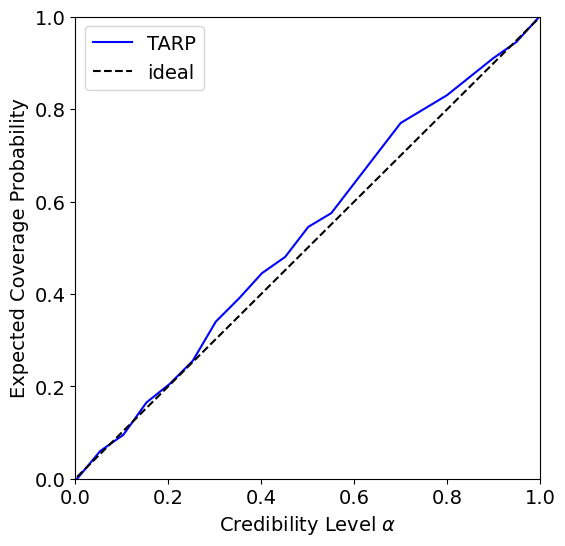

In [75]:
from sbi.analysis.plot import plot_tarp
plot_tarp(ecp.cpu(), alpha.cpu())